# Notebook 02 — Deseasonalization

Extracts stochastic residuals from hourly German electricity log-prices (DE-LU zone, 2023–2025) and temperature observations (Berlin, 2020–2025). Temperature is deseasonalized by OLS Fourier regression (trend + daily + annual harmonics + day×year interactions). Log-prices are deseasonalized by Paraschiv's multiplicative decomposition (F2Y × F2D). Price residuals are further cleaned of extreme spikes via 0.5%/99.5% quantile thresholding with local linear interpolation.

**Inputs:** ENTSOE API (prices), Open-Meteo API (temperature)  
**Outputs:** `data/deseasonalised/temp_resid.csv`, `data/deseasonalised/price_resid.csv`, `data/deseasonalised/price_resid_dejumped.csv`

### Import Prices


In [3]:
from pathlib import Path
import os
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("ENTSOE_API_KEY")
print("key =", api_key[:5], "...")

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(exist_ok=True)

load_dotenv(PROJECT_ROOT / ".env")
API_KEY = os.getenv("ENTSOE_API_KEY")
if not API_KEY:
    raise RuntimeError("ENTSOE_API_KEY not found in environment")

key = d1f8b ...


In [2]:
import pandas as pd
from entsoe import EntsoePandasClient

client = EntsoePandasClient(api_key=API_KEY)
ZONE = "DE_LU"

start = pd.Timestamp("2023-01-01", tz="UTC")
end_exclusive = pd.Timestamp("2025-12-31", tz="UTC")  

prices = client.query_day_ahead_prices(ZONE, start=start, end=end_exclusive)

prices_df = prices.to_frame(name="price_eur_mwh")
prices_df.index.name = "datetime"
prices_df = prices_df.tz_convert("UTC")
prices_df.head()  


KeyboardInterrupt: 

### Import Temperature


In [4]:
import pandas as pd
import openmeteo_requests
import requests_cache
from retry_requests import retry

cache_session = requests_cache.CachedSession(".cache", expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

latitude = 52.52 #for helsinki
longitude = 13.41

url = "https://archive-api.open-meteo.com/v1/archive"  

params = {
    "latitude": latitude,
    "longitude": longitude,
    "hourly": ["temperature_2m"],
    "timezone": "UTC",                 
    "start_date": "2020-01-01",
    "end_date": "2025-12-31",          
}

responses = openmeteo.weather_api(url, params=params)
response = responses[0]

hourly = response.Hourly()
temperature_2m = hourly.Variables(0).ValuesAsNumpy()

time_index = pd.date_range(
    start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
    end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
    freq=pd.Timedelta(seconds=hourly.Interval()),
    inclusive="left",
)

temp_df = pd.DataFrame({"temperature_c": temperature_2m}, index=time_index) #pandas series with datetime index
temp_df.index.name = "datetime"
temp_df.head()


,temperature_c
datetime,
2020-01-01 00:00:00+00:00,2.05
2020-01-01 01:00:00+00:00,1.75
2020-01-01 02:00:00+00:00,1.15
2020-01-01 03:00:00+00:00,0.30
2020-01-01 04:00:00+00:00,-0.10


### Deseasonalise temperature : Fourier-based seasonal regression

The temperature series $y_t$ is modeled as the sum of a trend, seasonal components, and a residual:

$$
y_t = T(x_t) + f_{day}(x_t) + f_{year}(x_t) + f_{inter}(x_t) + \varepsilon_t
$$

The trend component is assumed to be linear:

$$
T(x_t) = \beta_0 + \beta_1 x_t
$$

where $x_t$ is the time index (in hours).

Seasonal effects are approximated using truncated Fourier series:

$$
f_P(x_t) =
\sum_{k=1}^{K}
\left[
a_k \cos\left(\frac{2\pi k x_t}{P}\right)
+
b_k \sin\left(\frac{2\pi k x_t}{P}\right)
\right]
$$

Two seasonal components are included:

$$
f_{day}(x_t) \quad (P_{day} = 24)
$$

$$
f_{year}(x_t) \quad (P_{year} = 365.25 \times 24)
$$

To allow the daily cycle to vary during the year, interaction terms are introduced as products of the Fourier bases:

$$
f_{inter}(x_t) =
\sum_{i=1}^{2K_{day}}
\sum_{j=1}^{2K_{year}}
c_{ij}
\, f^{day}_i(x_t) \, f^{year}_j(x_t)
$$

Parameters are estimated by ordinary least squares:

$$
\hat{\beta} = \arg\min_{\beta} \|y - X\beta\|^2
$$

The deseasonalized series is obtained from the residuals:

$$
r_t = y_t - \hat{y}_t
$$      


In [5]:
import numpy as np
import pandas as pd

P_day = 24
P_year = 365.25 * 24
K_day = 3
K_year = 3

# Sort, enforce hourly frequency, fill any missing hours by linear interpolation
temp = temp_df["temperature_c"].sort_index().asfreq("h").interpolate(method="linear")

# Hours elapsed since the start of the series
xt = ((temp.index - temp.index[0]) / pd.Timedelta(hours=1)).to_numpy(dtype=float)

def fourier_block(x, period, K):
    omega = 2 * np.pi / period
    cols = []
    for k in range(1, K + 1):
        cols.append(np.cos(k * omega * x))
        cols.append(np.sin(k * omega * x))
    return np.column_stack(cols)

X_intercept_trend = [np.ones_like(xt), xt]
block_day  = fourier_block(xt, P_day,  K_day)
block_year = fourier_block(xt, P_year, K_year)

# Interaction terms: each daily Fourier component × each annual Fourier component
inter_cols = []
for i in range(block_day.shape[1]):
    for j in range(block_year.shape[1]):
        inter_cols.append(block_day[:, i] * block_year[:, j])

block_inter = np.column_stack(inter_cols)

Xt = np.column_stack(X_intercept_trend + [block_day, block_year, block_inter])

betat, *_ = np.linalg.lstsq(Xt, temp.values, rcond=None)
temp_fit   = Xt @ betat
temp_resid = pd.Series(temp.values - temp_fit, index=temp.index, name="temp_deseasoned")

# Build coefficient names for readability
names = ["intercept", "trend"]
for k in range(1, K_day + 1):
    names += [f"day_cos_{k}", f"day_sin_{k}"]
for k in range(1, K_year + 1):
    names += [f"year_cos_{k}", f"year_sin_{k}"]
for i in range(block_day.shape[1]):
    for j in range(block_year.shape[1]):
        names.append(f"inter_{i}_{j}")

coef    = pd.Series(betat, index=names, name="coefficient")
coef_df = coef.reset_index()
coef_df.columns = ["term", "value"]

print(coef)
print(temp_resid.head())

intercept     10.690454
trend          0.000009
day_cos_1     -2.773715
day_sin_1     -1.343266
day_cos_2      0.531358
day_sin_2      0.000696
day_cos_3      0.138540
day_sin_3      0.080035
year_cos_1    -8.946296
year_sin_1    -3.018553
year_cos_2     0.302592
year_sin_2     0.767941
year_cos_3     0.010468
year_sin_3     0.349874
inter_0_0      1.607171
inter_0_1     -0.312688
inter_0_2      0.475547
inter_0_3     -0.059336
inter_0_4     -0.078006
inter_0_5      0.022845
inter_1_0      0.756810
inter_1_1     -0.159529
inter_1_2      0.259840
inter_1_3     -0.126255
inter_1_4     -0.034853
inter_1_5      0.044449
inter_2_0      0.223024
inter_2_1     -0.054528
inter_2_2     -0.334527
inter_2_3      0.106636
inter_2_4     -0.053900
inter_2_5     -0.004609
inter_3_0      0.260987
inter_3_1      0.050532
inter_3_2     -0.079633
inter_3_3      0.099711
inter_3_4     -0.034754
inter_3_5     -0.016093
inter_4_0     -0.384988
inter_4_1      0.065902
inter_4_2     -0.028586
inter_4_3      0

In [7]:
coef_trend = coef[["intercept", "trend"]]
coef_day = coef[[n for n in coef.index if n.startswith("day_")]]
coef_year = coef[[n for n in coef.index if n.startswith("year_")]]
coef_inter = coef[[n for n in coef.index if n.startswith("inter_")]]

print("Trend")
print(coef_trend)

print("\nDay")
print(coef_day)

print("\nYear")
print(coef_year)

print("\nInteractions")
pd.set_option("display.max_rows", None)
print(coef_inter)

Trend
intercept    10.690454
trend         0.000009
Name: coefficient, dtype: float64

Day
day_cos_1   -2.773715
day_sin_1   -1.343266
day_cos_2    0.531358
day_sin_2    0.000696
day_cos_3    0.138540
day_sin_3    0.080035
Name: coefficient, dtype: float64

Year
year_cos_1   -8.946296
year_sin_1   -3.018553
year_cos_2    0.302592
year_sin_2    0.767941
year_cos_3    0.010468
year_sin_3    0.349874
Name: coefficient, dtype: float64

Interactions
inter_0_0    1.607171
inter_0_1   -0.312688
inter_0_2    0.475547
inter_0_3   -0.059336
inter_0_4   -0.078006
inter_0_5    0.022845
inter_1_0    0.756810
inter_1_1   -0.159529
inter_1_2    0.259840
inter_1_3   -0.126255
inter_1_4   -0.034853
inter_1_5    0.044449
inter_2_0    0.223024
inter_2_1   -0.054528
inter_2_2   -0.334527
inter_2_3    0.106636
inter_2_4   -0.053900
inter_2_5   -0.004609
inter_3_0    0.260987
inter_3_1    0.050532
inter_3_2   -0.079633
inter_3_3    0.099711
inter_3_4   -0.034754
inter_3_5   -0.016093
inter_4_0   -0.384988
i

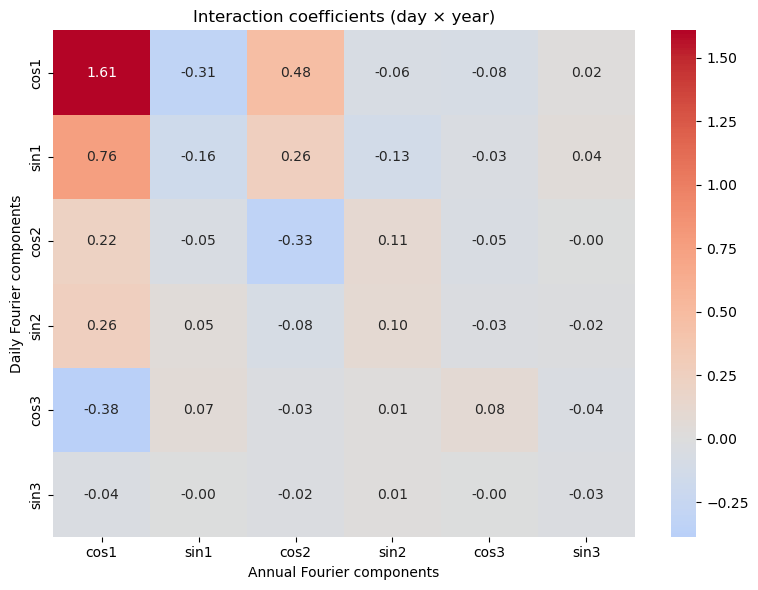

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

n_day  = block_day.shape[1]
n_year = block_year.shape[1]

inter_matrix = np.zeros((n_day, n_year))
k = 0
for i in range(n_day):
    for j in range(n_year):
        inter_matrix[i, j] = coef_inter.iloc[k]
        k += 1

day_labels  = [f"cos{k}" if i % 2 == 0 else f"sin{k}"
               for k in range(1, K_day + 1) for i in range(2)]
year_labels = [f"cos{k}" if i % 2 == 0 else f"sin{k}"
               for k in range(1, K_year + 1) for i in range(2)]

plt.figure(figsize=(8, 6))
sns.heatmap(
    inter_matrix,
    xticklabels=year_labels,
    yticklabels=day_labels,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.xlabel("Annual Fourier components")
plt.ylabel("Daily Fourier components")
plt.title("Interaction coefficients (day × year)")
plt.tight_layout()
plt.show()

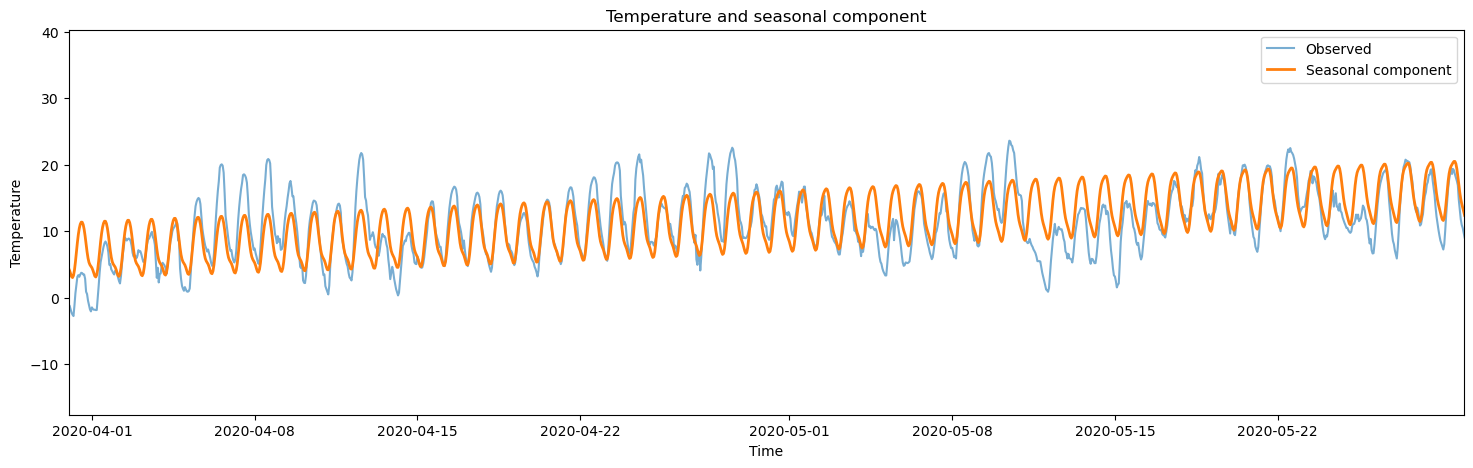

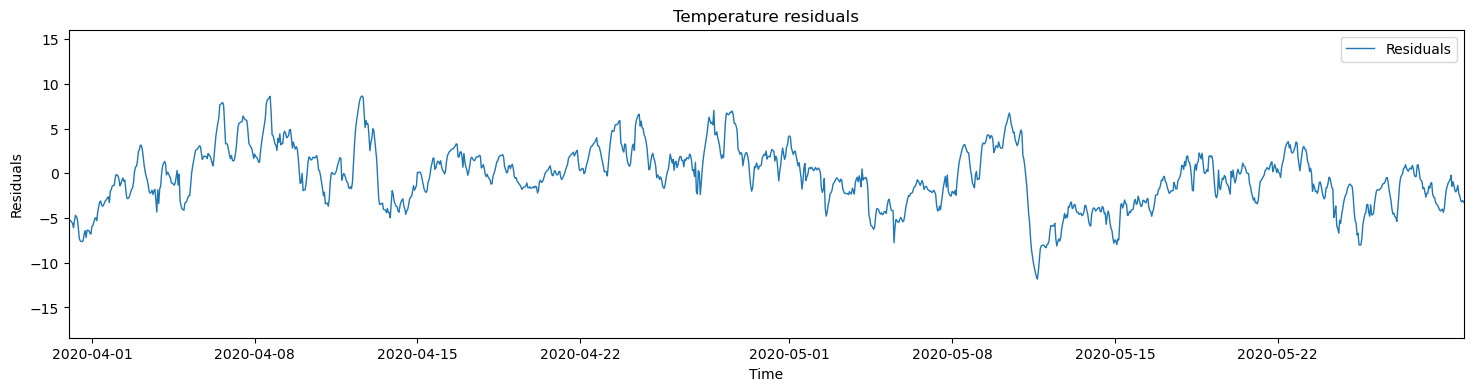

In [9]:
plt.figure(figsize=(18,5))
plt.plot(temp.index, temp.values, alpha=0.6, label="Observed")
plt.plot(temp.index, temp_fit, linewidth=2, label="Seasonal component")
plt.xlim(temp.index[24*30*3], temp.index[24*30*5])  
plt.legend()
plt.title("Temperature and seasonal component")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.show()

plt.figure(figsize=(18,4))
plt.plot(temp_resid.index, temp_resid.values, linewidth=1, label="Residuals")
plt.legend()
plt.xlim(temp.index[24*30*3], temp.index[24*30*5])  
plt.title("Temperature residuals")
plt.xlabel("Time")
plt.ylabel("Residuals")
plt.show()

#### Autocorrelation structure — before and after deseasonalization

The ACF of the raw temperature series shows strong periodicity at lags 24 h and 8760 h. After removing the deterministic seasonal component the ACF decays geometrically, confirming that the residual $r_t = y_t - \hat{y}_t$ is a weakly stationary process amenable to CARMA modelling.

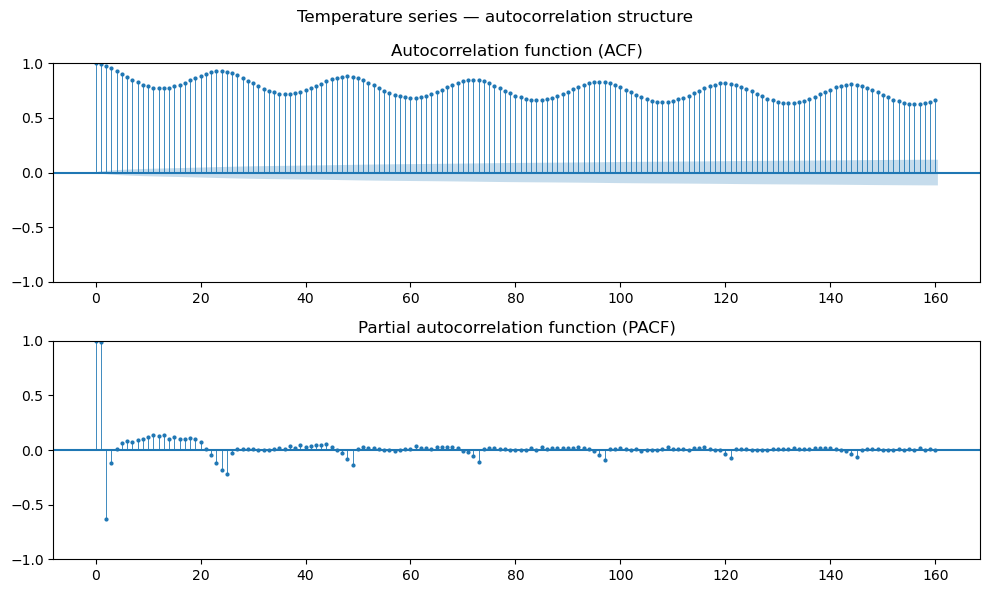

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 1, figsize=(10, 6))
fig.suptitle("Temperature series — autocorrelation structure")

plot_acf(temp,  lags=160, ax=axs[0], vlines_kwargs={"linewidth": 0.6}, markersize=2)
axs[0].set_title("Partial autocorrelation function (PACF)")

plot_pacf(temp, lags=160, ax=axs[1], vlines_kwargs={"linewidth": 0.6}, markersize=2)
axs[1].set_title("Partial autocorrelation function (PACF)")

plt.tight_layout()
plt.show()

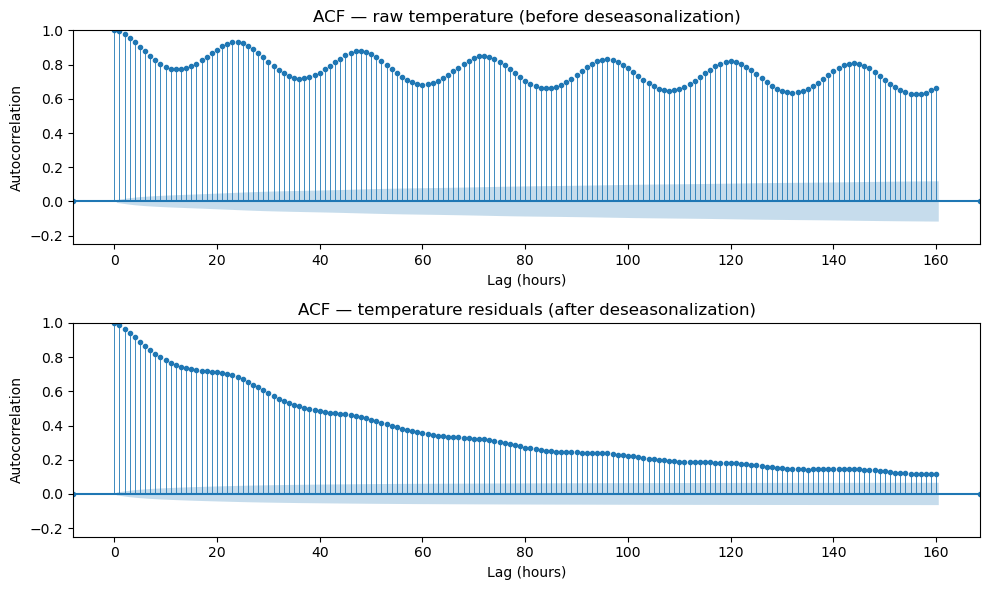

In [11]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 1, figsize=(10, 6))

plot_acf(temp, lags=160, ax=axs[0],
         vlines_kwargs={"linewidth": 0.6}, marker='o', markersize=3)
axs[0].set_title("ACF — raw temperature (before deseasonalization)")
axs[0].set_ylabel("Autocorrelation")
axs[0].set_xlabel("Lag (hours)")

plot_acf(temp_resid, lags=160, ax=axs[1],
         vlines_kwargs={"linewidth": 0.6}, marker='o', markersize=3)
axs[1].set_title("ACF — temperature residuals (after deseasonalization)")
axs[1].set_ylabel("Autocorrelation")
axs[1].set_xlabel("Lag (hours)")

axs[0].set_ylim(-0.25, 1)
axs[1].set_ylim(-0.25, 1)

plt.tight_layout()
plt.show()

In [12]:
temp_resid.to_frame(name="temp_deseasoned") \
           .rename_axis("datetime") \
           .to_csv("../data/deseasonalised/temp_resid.csv")

In [13]:
import pandas as pd

temp_resid = pd.read_csv("../data/deseasonalised/temp_resid.csv", index_col=0)
temp_res = temp_resid["temp_deseasoned"].copy()
time_temp = temp_res.index.copy()

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller, kpss

### Residual diagnostics — temperature

Assesses stationarity and distributional properties of the deseasonalized temperature residuals $r_t^Y = y_t - \hat{y}_t^{\text{seas}}$. A histogram and normal QQ-plot test for Gaussianity; summary statistics (mean, standard deviation, skewness, excess kurtosis) quantify departures from normality that motivate the NIG distribution in the Lévy fitting step (notebook 06).

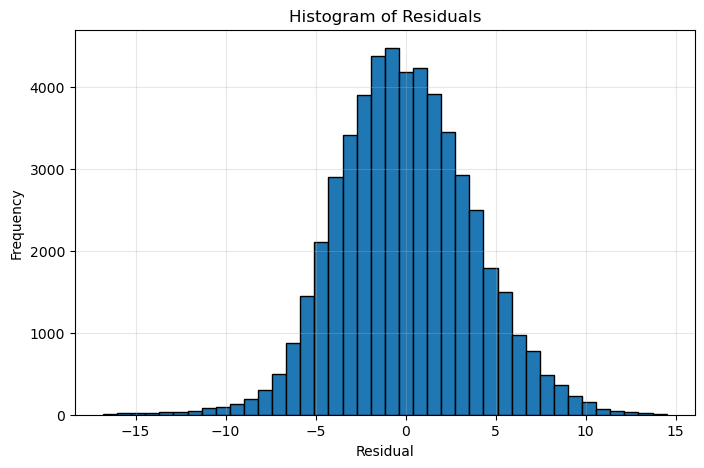

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(temp_resid, bins=40, edgecolor="black")
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

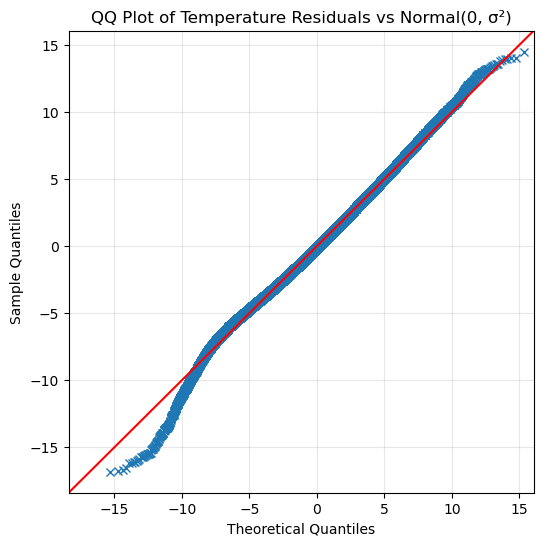

In [16]:
# ensure Series
temp_series = temp_resid.squeeze()

plt.figure(figsize=(6, 6))
qqplot(temp_series,
       dist=norm,
       loc=0,
       scale=np.std(temp_series),
       line='45',
       marker='x',
       ax=plt.gca())

plt.title("QQ Plot of Temperature Residuals vs Normal(0, σ²)")
plt.grid(alpha=0.3)
plt.show()

In [17]:
temp_series = temp_resid.squeeze()
summary_stats_temp = pd.DataFrame({
    "Value": [
        temp_series.count(),
        temp_series.mean(),
        temp_series.std(),
        temp_series.min(),
        temp_series.quantile(0.25),
        temp_series.median(),
        temp_series.quantile(0.75),
        temp_series.max(),
        stats.skew(temp_series, bias=False),
        stats.kurtosis(temp_series, fisher=True, bias=False)
    ]
}, index=[
    "Count",
    "Mean",
    "Std",
    "Min",
    "25%",
    "Median",
    "75%",
    "Max",
    "Skewness",
    "Excess Kurtosis"
])

print("Summary Statistics for Temperature Residuals\n")
print(summary_stats_temp.round(4))

Summary Statistics for Temperature Residuals

                      Value
Count            52608.0000
Mean                 0.0000
Std                  3.7241
Min                -16.8168
25%                 -2.5350
Median              -0.1347
75%                  2.4491
Max                 14.4909
Skewness             0.0576
Excess Kurtosis      0.4054


### Deseasonalise prices : Paraschiv's method

The spot price is decomposed into a deterministic seasonal component and a stochastic component:

$$
P_t = f_t + X_t
$$

where $f_t$ is the deterministic seasonality and $X_t$ the deseasonalized residual.

The deterministic component can be written as a trend plus seasonality:

$$
f_t = f_t^{trend} + f_t^{season}
$$

with linear trend

$$
f_t^{trend} = a^{trend} + b^{trend} t
$$

In the empirical implementation, the seasonal shape is constructed multiplicatively as:

$$
s_t = \bar P \, f2y_t \, f2d_t
$$

and the deseasonalized price is:

$$
X_t = P_t - s_t
$$

### Factor-to-year

Let $S_{day}(d)$ be the average spot price of day $d$. The factor-to-year is defined by:

$$
f2y_d
=
\frac{S_{day}(d)}
{\frac{1}{K(d)} \sum_{k \in year(d)} S_{day}(k)}
$$

where $K(d)$ is the number of days in the year containing day $d$.

It is modeled by the regression:

$$
f2y_d
=
\alpha_0
+
\sum_{i=1}^{6} b_i D_{d,i}
+
\sum_{i=1}^{12} c_i M_{d,i}
+
\sum_{i=1}^{3} d_i \, CDD_{d,i}
+
\sum_{i=1}^{3} e_i \, HDD_{d,i}
+
\varepsilon_d
$$

with

$$
CDD = \max(T - 18.3, 0)
$$

$$
HDD = \max(18.3 - T, 0)
$$

The daily factor is then converted to hourly frequency by:

$$
f2y_t = f2y_d \qquad \text{for all } t \in d
$$

### Factor-to-day

Let $S_{hour}(t)$ be the hourly spot price. The factor-to-day is defined by:

$$
f2d_t
=
\frac{S_{hour}(t)}
{\frac{1}{24}\sum_{k \in day(t)} S_{hour}(k)}
$$

Days are partitioned into 20 profile classes. For each class $c$, the intraday profile is estimated by:

$$
f2d_t
=
a_0^{(c)}
+
\sum_{i=1}^{23} b_i^{(c)} H_{t,i}
+
\varepsilon_t,
\qquad t \in c
$$

where $H_{t,i}$ are hour-of-day dummies.

### Final seasonal shape

The relative hourly seasonal weight is:

$$
sw_t = f2y_t \, f2d_t
$$

The deterministic seasonal component is then:

$$
s_t = \bar P \, sw_t = \bar P \, f2y_t \, f2d_t
$$

Finally, the deseasonalized price is:

$$
X_t = P_t - s_t
$$

In [18]:
prices_df = pd.read_csv("../data/raw/prices.csv", index_col=0)


In [19]:
print(prices_df.head())

                           price_eur_mwh
datetime                                
2023-01-01 00:00:00+00:00          -1.07
2023-01-01 01:00:00+00:00          -1.47
2023-01-01 02:00:00+00:00          -5.08
2023-01-01 03:00:00+00:00          -4.49
2023-01-01 04:00:00+00:00          -5.40


In [20]:
prices_df.index = pd.to_datetime(prices_df.index)
prices_df = prices_df.sort_index()


### Deseasonalization — log-price (Paraschiv multiplicative decomposition)

Applies the **log-price transformation** $\tilde{S}_t = \log(S_t + \delta)$ with shift $\delta = 1000$ EUR/MWh to map all prices to a positive domain. The seasonal component is then factored as

$$\hat{s}_t = \bar{p}\cdot F2D_t \cdot F2Y_t,$$

where $\bar{p}$ is the sample mean log-price, $F2D_t$ is the intra-day factor estimated from 20 profile classes (weekday/weekend $\times$ season), and $F2Y_t$ is the annual factor estimated by OLS with Fourier harmonics and HDD/CDD regressors.

The deseasonalized residual $r_t^X = \tilde{S}_t - \hat{s}_t$ is the input to ARMA order selection (notebook 03) and CARMA fitting (notebooks 05–07).

In [21]:
import numpy as np
import pandas as pd

# ============================================================
# Log-price transformation
# delta_shift = 1000 EUR/MWh ensures all arguments are positive
# ============================================================
delta_shift = 1000.0

price_raw = prices_df["price_eur_mwh"].copy().sort_index().asfreq("h").interpolate(method="linear")
price = np.log(price_raw + delta_shift)

print("Log-price stats:")
print(price.describe())
print(f"\nMin raw price: {price_raw.min():.2f} EUR/MWh  =>  log({price_raw.min() + delta_shift:.1f}) = {np.log(price_raw.min() + delta_shift):.6f}")

# ============================================================
# Factor-to-day (F2D)
# f2d_t = price_t / daily_mean(price)  for each hour t
# Estimated separately for each of the 20 profile classes
# (weekday/weekend × season), using hour-of-day dummies.
# ============================================================
day_mean = price.resample("D").mean()
day_mean_per_hour = day_mean.reindex(price.index.floor("D")).to_numpy(dtype=float)
f2d = price.to_numpy(dtype=float) / day_mean_per_hour

idx   = price.index
dow   = idx.dayofweek
month = idx.month

# Assign each hour to one of 20 profile classes:
# weekday months 1-12 → classes 1-12; Saturday/Sunday × 4 seasons → classes 13-20
profile_class = np.zeros(len(idx), dtype=int)
for i in range(len(idx)):
    m = month[i]
    d = dow[i]
    if d <= 4:
        profile_class[i] = m
    elif d == 5:
        if m in [1, 2, 12]:   profile_class[i] = 13
        elif m in [3, 4, 5]:  profile_class[i] = 14
        elif m in [6, 7, 8]:  profile_class[i] = 15
        else:                  profile_class[i] = 16
    elif d == 6:
        if m in [1, 2, 12]:   profile_class[i] = 17
        elif m in [3, 4, 5]:  profile_class[i] = 18
        elif m in [6, 7, 8]:  profile_class[i] = 19
        else:                  profile_class[i] = 20

hour_dummies = pd.get_dummies(idx.hour, drop_first=True).astype(float)
X_base = np.column_stack([np.ones(len(idx)), hour_dummies.to_numpy()])

f2d_hat    = np.zeros(len(idx), dtype=float)
class_ids  = np.unique(profile_class)

for class_id in class_ids:
    mask        = (profile_class == class_id)
    X_class     = X_base[mask]
    price_class = price[mask].to_numpy()
    coeffs, *_  = np.linalg.lstsq(X_class, price_class, rcond=None)
    predicted   = X_class @ coeffs
    mean_shape  = np.mean(predicted)
    f2d_hat[mask] = predicted / mean_shape if mean_shape != 0 else 1.0

averageprice = price.mean()

Log-price stats:
count    26281.000000
mean         6.990761
std          0.046718
min          6.214608
25%          6.970711
50%          6.994061
75%          7.014886
max          7.568524
Name: price_eur_mwh, dtype: float64

Min raw price: -500.00 EUR/MWh  =>  log(500.0) = 6.214608


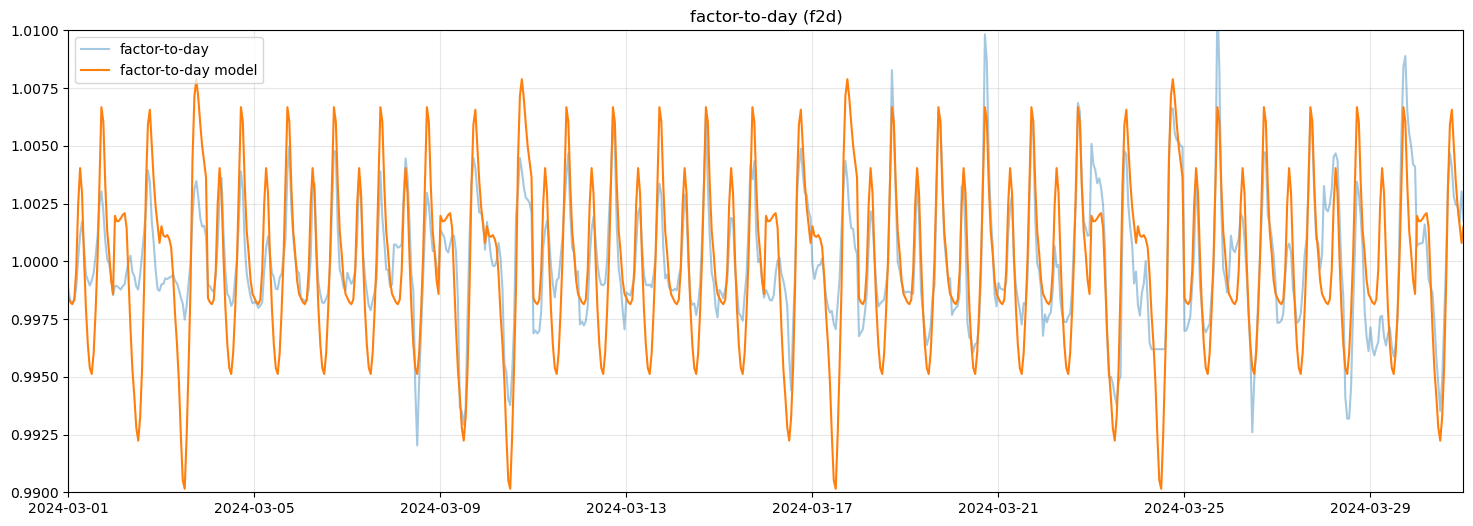

In [22]:
plt.figure(figsize=(18,6))
plt.plot(idx, f2d, alpha=0.4, label="factor-to-day")
plt.plot(idx, f2d_hat, label="factor-to-day model")

start_zoom = "2024-03-01"
end_zoom = "2024-03-31"
plt.xlim(pd.Timestamp(start_zoom), pd.Timestamp(end_zoom))
plt.ylim(0.99,1.01)
plt.title("factor-to-day (f2d)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


#### Factor-to-year (F2Y) estimation

Estimates the annual seasonal factor $F2Y_d$ by regressing the daily mean log-price on weekday dummies, month dummies (with August split into early/late), and heating/cooling degree-day regressors (base 15 °C):

$$F2Y_d = \alpha_0 + \sum_{i=1}^{6}\beta_i D_{d,i}^{\text{dow}} + \sum_{m\neq 8}\gamma_m \mathbf{1}_{\{d \in m\}} + \delta_1 \text{HDD}_d + \delta_2 \text{CDD}_d + \varepsilon_d.$$

The fitted daily factor is broadcast to hourly frequency by assigning each hour the value of its calendar day.

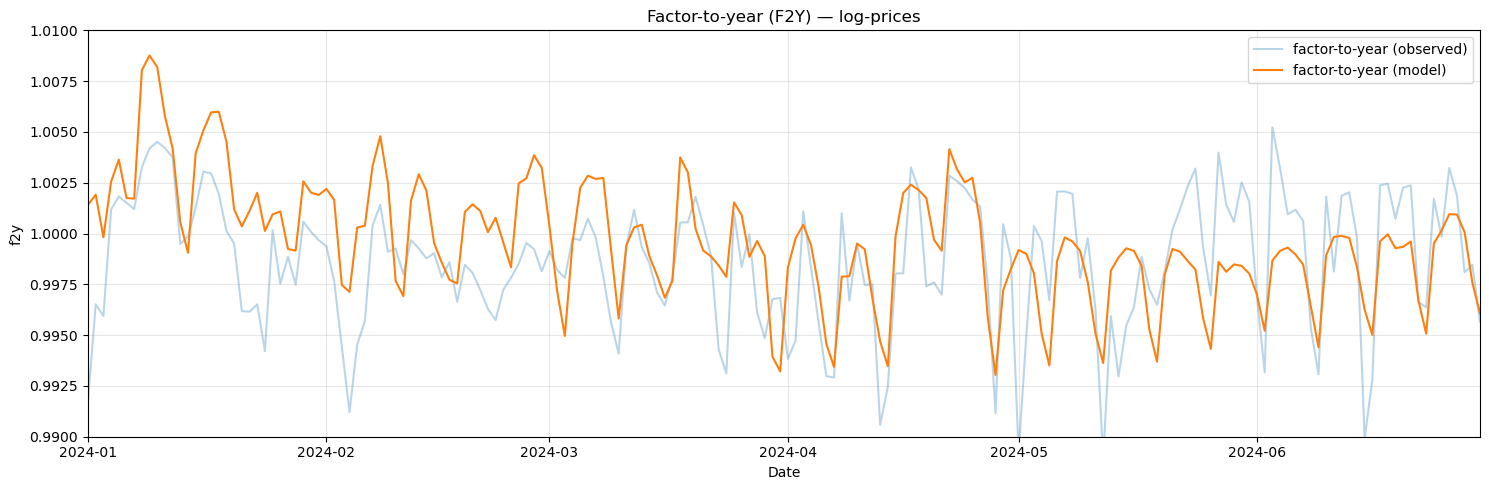

In [23]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Same log-price transformation (delta_shift = 1000 EUR/MWh)
delta_shift = 1000.0
price_raw = prices_df["price_eur_mwh"].copy().sort_index().asfreq("h").interpolate(method="linear")
price = np.log(price_raw + delta_shift)

S_day    = price.resample("D").mean()
temp_day = temp.resample("D").mean()

combined_base = (
    pd.concat([S_day.rename("price_eur_mwh"), temp_day.rename("temperature_c")],
              axis=1, join="inner")
    .dropna()
)
S_day    = combined_base["price_eur_mwh"]
temp_day = combined_base["temperature_c"]

# Factor-to-year: ratio of daily average price to annual average price
yearly_mean = S_day.groupby(S_day.index.year).transform("mean")
y = (S_day / yearly_mean).dropna()

X = pd.DataFrame(index=y.index)

# Weekday dummies (Mon–Sat; Sunday is the reference)
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
for d, lbl in enumerate(day_labels):
    X[lbl] = (X.index.dayofweek == d).astype(int)

# Month dummies (reference = August, split into two halves below)
for m in range(2, 13):
    if m != 8:
        X[f"Month_{m}"] = (X.index.month == m).astype(int)

# August split to capture early/late-summer effect
X["Aug_early"] = ((X.index.month == 8) & (X.index.day <= 15)).astype(int)
X["Aug_late"]  = ((X.index.month == 8) & (X.index.day  > 15)).astype(int)

# Heating and cooling degree days (base temperature 15 °C)
t = temp_day.reindex(y.index)
X["HDD"] = (15 - t).clip(lower=0)
X["CDD"] = (t - 15).clip(lower=0)

X = sm.add_constant(X)

df_model = pd.concat([y.rename("y"), X], axis=1).dropna()
y2 = df_model["y"]
X2 = df_model.drop(columns=["y"])

model_f2y  = sm.OLS(y2, X2).fit()
f2y_d_hat  = model_f2y.fittedvalues

plt.figure(figsize=(15, 5))
plt.plot(y2.index, y2, label="factor-to-year (observed)", alpha=0.3)
plt.plot(f2y_d_hat.index, f2y_d_hat, label="factor-to-year (model)")
plt.legend()

start_zoom = "2024-01-01"
end_zoom   = "2024-06-30"
plt.xlim(pd.Timestamp(start_zoom), pd.Timestamp(end_zoom))
plt.ylim(0.99, 1.01)
plt.title("Factor-to-year (F2Y) — log-prices")
plt.xlabel("Date")
plt.ylabel("f2y")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Final seasonal component and deseasonalized log-price residuals

Combines the estimated factors into the full multiplicative seasonal component:
$$\hat{s}_t = \bar{p}\cdot F2D_t \cdot F2Y_t.$$
The deseasonalized residual $r_t^X = \tilde{S}_t - \hat{s}_t$ is saved to `price_resid.csv` and passed to notebook 03 for ARMA order selection.

In [24]:
# Broadcast daily f2y to hourly: each hour inherits the value of its calendar day
f2y_t_hat = f2y_d_hat.reindex(price.index.floor("D")).to_numpy()
f2y_t_hat = pd.Series(f2y_t_hat, index=price.index, name="f2y_t_hat")

# Composite seasonal weight: sw_t = f2y_t * f2d_t
sw_t = f2y_t_hat * f2d_hat
yearly_avg = np.mean(price.values)

# Deterministic seasonal component: s_t = avg_log_price * sw_t
price_fit = pd.Series(sw_t * yearly_avg, index=price.index)

# Deseasonalized log-price residual
price_resid = (price - price_fit).rename("price_deseasoned")

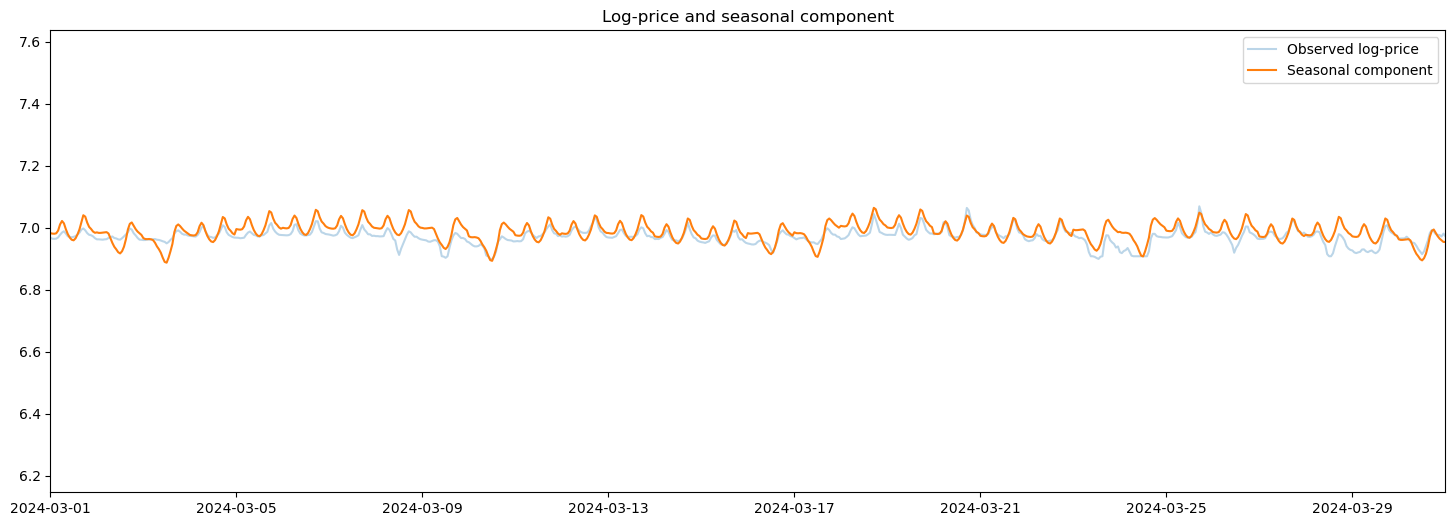

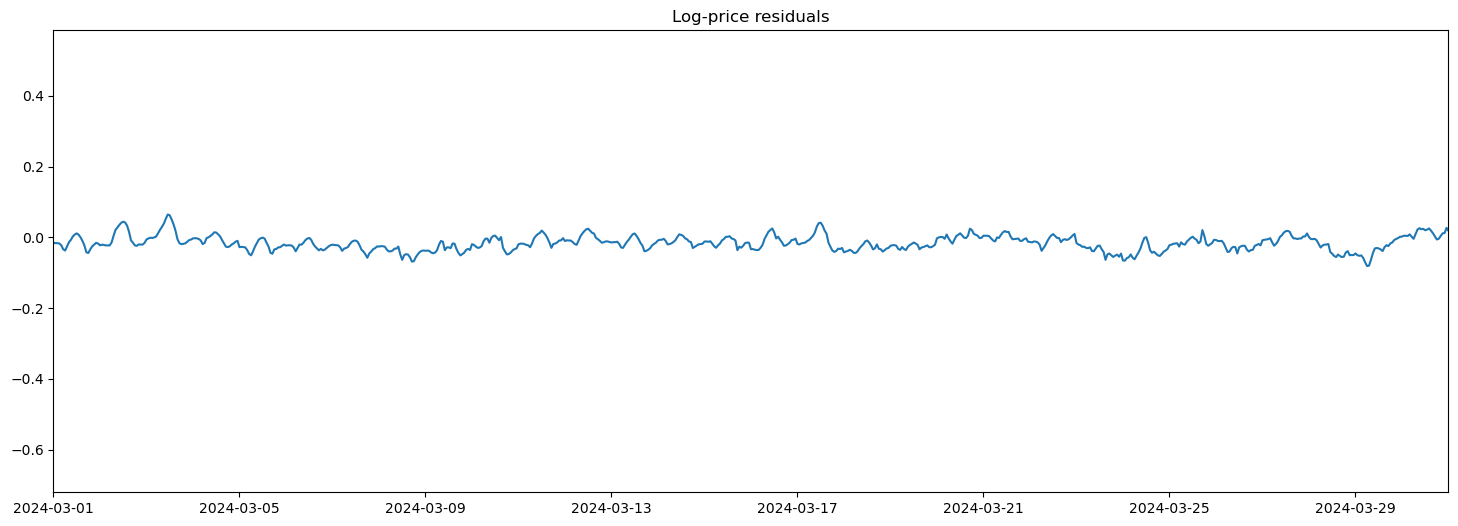

In [25]:
plt.figure(figsize=(18, 6))
plt.plot(price.index, price, alpha=0.3, label="Observed log-price")
plt.plot(price.index, price_fit, label="Seasonal component")
start_zoom = "2024-03-01"
end_zoom = "2024-03-31"
plt.xlim(pd.Timestamp(start_zoom), pd.Timestamp(end_zoom))
plt.title("Log-price and seasonal component")
plt.legend()

plt.figure(figsize=(18, 6))
plt.plot(idx, price_resid)
start_zoom = "2024-03-01"
end_zoom = "2024-03-31"
plt.xlim(pd.Timestamp(start_zoom), pd.Timestamp(end_zoom))
plt.title("Log-price residuals")
plt.show()

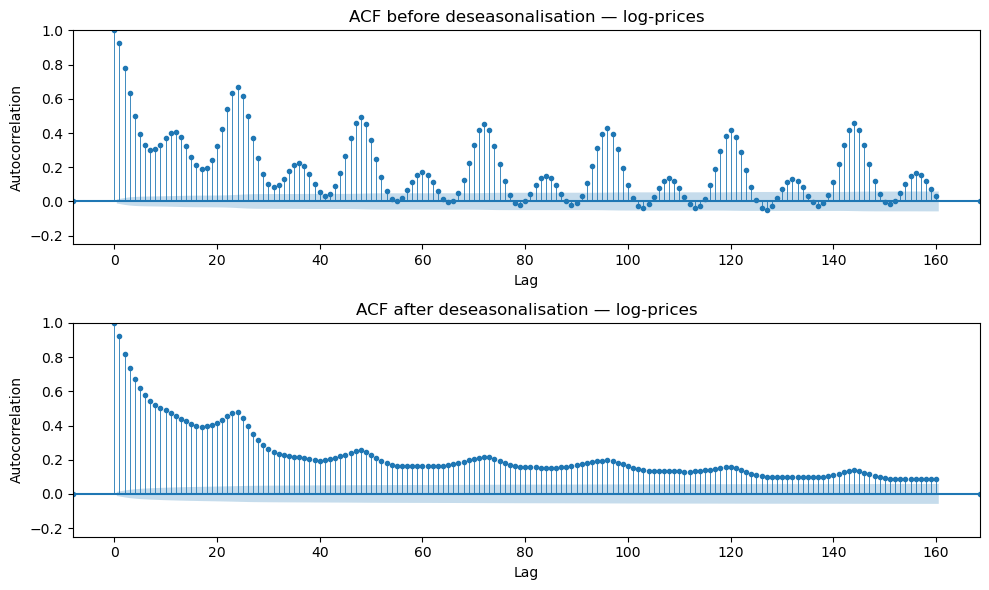

In [26]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axs = plt.subplots(2, 1, figsize=(10, 6))

plot_acf(price, lags=160, ax=axs[0],
         vlines_kwargs={"linewidth":0.6},
         marker='o', markersize=3)
axs[0].set_title("ACF before deseasonalisation — log-prices")
axs[0].set_ylabel("Autocorrelation")
axs[0].set_xlabel("Lag")

plot_acf(price_resid, lags=160, ax=axs[1],
         vlines_kwargs={"linewidth":0.6},
         marker='o', markersize=3)
axs[1].set_title("ACF after deseasonalisation — log-prices")
axs[1].set_ylabel("Autocorrelation")
axs[1].set_xlabel("Lag")

axs[0].set_ylim(-0.25, 1)
axs[1].set_ylim(-0.25, 1)

plt.tight_layout()
plt.show()

In [27]:
price_resid.to_frame(name="price_deseasoned") \
           .rename_axis("datetime") \
           .to_csv("../data/deseasonalised/price_resid.csv")

In [28]:
import pandas as pd

price_resid = pd.read_csv("../data/deseasonalised/price_resid.csv", index_col=0)
price_res = price_resid["price_deseasoned"].copy()
time_price = price_res.index.copy()

### Residual diagnostics — log-prices

Analogous diagnostic suite applied to the deseasonalized log-price residuals $r_t^X$. Heavy tails and positive excess kurtosis are expected due to price spikes; the jump-detection step below will isolate these extremes before CARMA fitting.

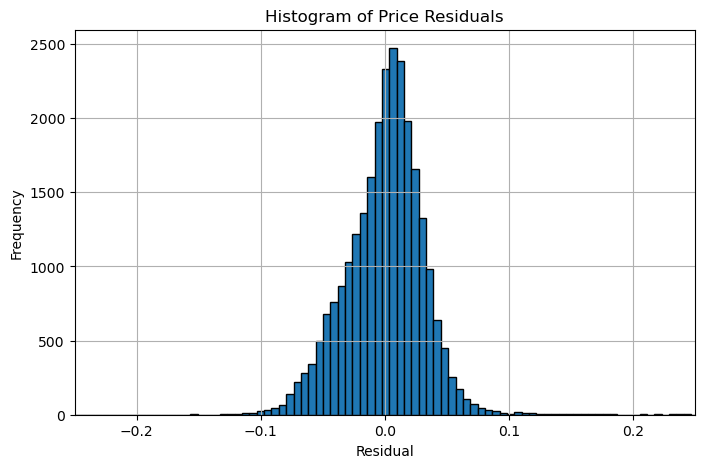

In [32]:
plt.figure(figsize=(8, 5))
plt.hist(price_resid, bins=200, edgecolor="black")
plt.xlim(-0.25, 0.25)
plt.title("Histogram of Price Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(alpha=1)
plt.show()

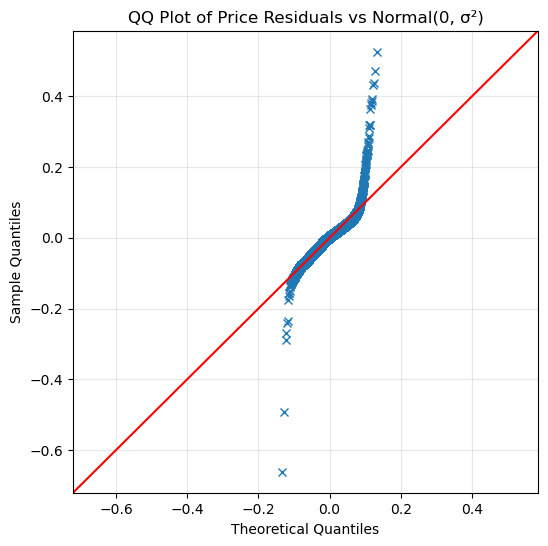

In [33]:
from scipy.stats import norm
from statsmodels.graphics.gofplots import qqplot
import numpy as np
import matplotlib.pyplot as plt

# ensure Series
price_series = price_resid.squeeze()
 
 
plt.figure(figsize=(6, 6))
qqplot(price_series,
       dist=norm,
       loc=0,
       scale=np.std(price_series),
       line='45',
       marker='x',
       ax=plt.gca())

plt.title("QQ Plot of Price Residuals vs Normal(0, σ²)")
plt.grid(alpha=0.3)
plt.show()

In [34]:
price_series = price_resid.squeeze()
summary_stats_price = pd.DataFrame({
    "Value": [
        price_series.count(),
        price_series.mean(),
        price_series.std(),
        price_series.min(),
        price_series.quantile(0.25),
        price_series.median(),
        price_series.quantile(0.75),
        price_series.max(),
        stats.skew(price_series, bias=False),
        stats.kurtosis(price_series, fisher=True, bias=False)
    ]
}, index=[
    "Count",
    "Mean",
    "Std",
    "Min",
    "25%",
    "Median",
    "75%",
    "Max",
    "Skewness",
    "Excess Kurtosis"
])

print(summary_stats_price.round(4))

                      Value
Count            26281.0000
Mean                 0.0000
Std                  0.0336
Min                 -0.6614
25%                 -0.0189
Median               0.0026
75%                  0.0193
Max                  0.5261
Skewness             0.5699
Excess Kurtosis     21.1093


### Spike detection and removal — log-price residuals

Extreme spikes in electricity prices (e.g., scarcity events, curtailment) produce outliers that are inconsistent with the continuous diffusion component of the CARMA model. They are identified by quantile thresholding: any observation outside $[q_{0.5\%},\, q_{99.5\%}]$ is flagged as a jump.

The jump component at a flagged observation $t$ is estimated as the excess above/below the threshold:

$$\hat{J}_t = \begin{cases} y_t - q_{99.5\%} & \text{if } y_t > q_{99.5\%} \\ y_t - q_{0.5\%} & \text{if } y_t < q_{0.5\%} \\ 0 & \text{otherwise} \end{cases}$$

The cleaned series $\tilde{y}_t$ replaces jump timestamps with linearly interpolated values. The jump flags and sizes are preserved in the output CSV for diagnostics.

=== JUMP THRESHOLDS ===
  Negative threshold (q=0.005): -0.0888
  Positive threshold (q=0.995): 0.1003
  Positive jumps detected: 132
  Negative jumps detected: 132
  Total jumps:             264

=== JUMP INTENSITIES (empirical Poisson) ===
  lambda+ per hour:  0.005023  (0.1205 per day)
  lambda- per hour:  0.005023  (0.1205 per day)
  lambda  per hour:  0.010045  (0.2411 per day)

=== JUMP SIZES ===
  Positive: mean = 0.0771, std = 0.0860
  Negative: mean = 0.0283, std = 0.0660

=== LOGNORMAL FIT ON JUMP SIZES ===
  pos_lognorm: {'shape': np.float64(1.3790717485975992), 'loc': 0, 'scale': np.float64(0.0382525918053868)}
  neg_lognorm: {'shape': np.float64(1.4166879138692914), 'loc': 0, 'scale': np.float64(0.01061791713217233)}

Saved: ../data/deseasonalised/price_resid_dejumped.csv


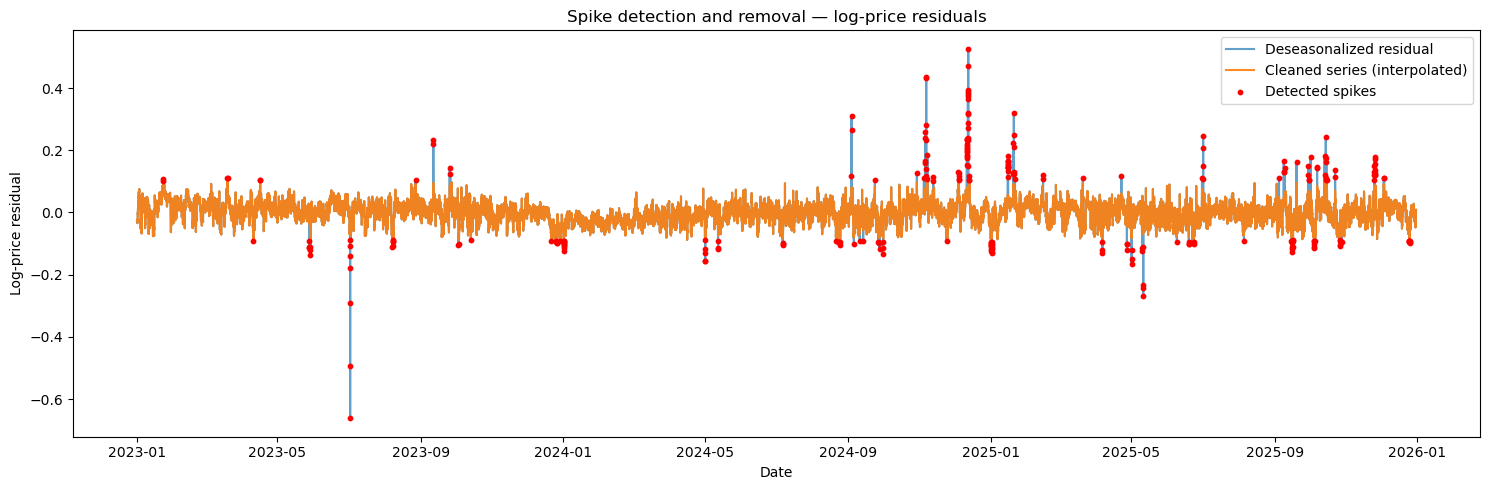

In [35]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# ============================================================
# 0. Load data
# ============================================================
price_resid = pd.read_csv("../data/deseasonalised/price_resid.csv", index_col=0)
price_res   = price_resid["price_deseasoned"].copy()
time_price  = pd.to_datetime(price_res.index)

y      = price_res.to_numpy(dtype=float)
series = pd.Series(y, index=time_price, name="y")

# ============================================================
# 1. Jump identification via extreme quantile thresholds
# ============================================================
q_low  = 0.005
q_high = 0.995

thr_neg = series.quantile(q_low)
thr_pos = series.quantile(q_high)

jump_pos_mask = series > thr_pos
jump_neg_mask = series < thr_neg
jump_mask     = jump_pos_mask | jump_neg_mask

print(f"=== JUMP THRESHOLDS ===")
print(f"  Negative threshold (q={q_low:.3f}): {thr_neg:.4f}")
print(f"  Positive threshold (q={q_high:.3f}): {thr_pos:.4f}")
print(f"  Positive jumps detected: {jump_pos_mask.sum()}")
print(f"  Negative jumps detected: {jump_neg_mask.sum()}")
print(f"  Total jumps:             {jump_mask.sum()}")

# ============================================================
# 2. Empirical Poisson intensity (hourly and daily)
# ============================================================
n       = len(series)
n_pos   = int(jump_pos_mask.sum())
n_neg   = int(jump_neg_mask.sum())

lambda_pos   = n_pos  / n
lambda_neg   = n_neg  / n
lambda_total = (n_pos + n_neg) / n

print(f"\n=== JUMP INTENSITIES (empirical Poisson) ===")
print(f"  lambda+ per hour:  {lambda_pos:.6f}  ({24 * lambda_pos:.4f} per day)")
print(f"  lambda- per hour:  {lambda_neg:.6f}  ({24 * lambda_neg:.4f} per day)")
print(f"  lambda  per hour:  {lambda_total:.6f}  ({24 * lambda_total:.4f} per day)")

# ============================================================
# 3. Jump size distribution (excess above/below threshold)
# ============================================================
jump_sizes_pos = (series[jump_pos_mask] - thr_pos).to_numpy()
jump_sizes_neg = (thr_neg - series[jump_neg_mask]).to_numpy()

print(f"\n=== JUMP SIZES ===")
if len(jump_sizes_pos) > 0:
    print(f"  Positive: mean = {jump_sizes_pos.mean():.4f}, std = {jump_sizes_pos.std(ddof=1):.4f}")
if len(jump_sizes_neg) > 0:
    print(f"  Negative: mean = {jump_sizes_neg.mean():.4f}, std = {jump_sizes_neg.std(ddof=1):.4f}")

# ============================================================
# 4. Lognormal fit on jump magnitudes (compound Poisson model)
# ============================================================
fit_results = {}
if len(jump_sizes_pos) > 0:
    shape_p, loc_p, scale_p = stats.lognorm.fit(jump_sizes_pos, floc=0)
    fit_results["pos_lognorm"] = {"shape": shape_p, "loc": loc_p, "scale": scale_p}
if len(jump_sizes_neg) > 0:
    shape_n, loc_n, scale_n = stats.lognorm.fit(jump_sizes_neg, floc=0)
    fit_results["neg_lognorm"] = {"shape": shape_n, "loc": loc_n, "scale": scale_n}

print(f"\n=== LOGNORMAL FIT ON JUMP SIZES ===")
for k, v in fit_results.items():
    print(f"  {k}: {v}")

# ============================================================
# 5. Cleaned series: replace jump timestamps by interpolation
# ============================================================
# Estimate the jump component as the excess above/below the threshold
jump_component = pd.Series(0.0, index=series.index, name="jump_component")
jump_component[jump_pos_mask] = series[jump_pos_mask] - thr_pos
jump_component[jump_neg_mask] = series[jump_neg_mask] - thr_neg

# Replace flagged observations with NaN and interpolate linearly
series_clean = series.copy()
series_clean[jump_mask] = np.nan
series_clean = series_clean.interpolate(method="time").bfill().ffill()
series_clean.name = "y_dejumped_interp"

# ============================================================
# 6. Build output DataFrame and save
# ============================================================
out = pd.DataFrame({
    "y":                series,
    "jump_component":   jump_component,
    "y_minus_jump":     series - jump_component,
    "y_dejumped_interp": series_clean,
    "is_jump_pos":      jump_pos_mask.astype(int),
    "is_jump_neg":      jump_neg_mask.astype(int),
    "is_jump":          jump_mask.astype(int),
})

out.to_csv("../data/deseasonalised/price_resid_dejumped.csv")
print("\nSaved: ../data/deseasonalised/price_resid_dejumped.csv")

# ============================================================
# 7. Diagnostic plot
# ============================================================
plt.figure(figsize=(15, 5))
plt.plot(out.index, out["y"],                label="Deseasonalized residual", alpha=0.7)
plt.plot(out.index, out["y_dejumped_interp"], label="Cleaned series (interpolated)", alpha=0.9)
plt.scatter(out.index[out["is_jump"] == 1], out.loc[out["is_jump"] == 1, "y"],
            s=10, color="red", label="Detected spikes", zorder=5)
plt.legend()
plt.title("Spike detection and removal — log-price residuals")
plt.xlabel("Date")
plt.ylabel("Log-price residual")
plt.tight_layout()
plt.show()

In [36]:
import pandas as pd
import numpy as np
from pathlib import Path

# Temperature seasonal component (Fourier fit) as a Series
temp_seasonal = pd.Series(temp_fit, index=temp.index, name="temp_seasonal")

# Log-price seasonal component = deterministic fit + spikes removed
# price_fit is the Paraschiv seasonal shape; jump_component holds the spikes
# extracted from the deseasoned residuals — together they represent everything
# that was removed from the observed log-price to obtain the CARMA input.
log_price_seasonal = (price_fit + jump_component).rename("log_price_seasonal")

# Restrict to the intersection where both series are defined
common_index = temp_seasonal.index.intersection(log_price_seasonal.index)

seasonalities = pd.DataFrame({
    "temp_seasonal": temp_seasonal.loc[common_index],
    "log_price_seasonal": log_price_seasonal.loc[common_index],
}, index=common_index)
seasonalities.index.name = "datetime"

out_path = Path("../data/deseasonalised/seasonalities.csv")
seasonalities.to_csv(out_path)
print(f"Saved {len(seasonalities):,} rows to {out_path}")
print(seasonalities.head())


Saved 26,281 rows to ..\data\deseasonalised\seasonalities.csv
                           temp_seasonal  log_price_seasonal
datetime                                                    
2023-01-01 00:00:00+00:00       1.700993            6.933008
2023-01-01 01:00:00+00:00       1.728381            6.930543
2023-01-01 02:00:00+00:00       1.780817            6.927347
2023-01-01 03:00:00+00:00       1.796461            6.926368
2023-01-01 04:00:00+00:00       1.738400            6.927054
